# 🌍 Global Sustainability & Happiness Analysis

**Author:** Divyanshi Shaw  
**Degree:** Master of Business Analytics, Deakin University  
**Tools:** Python · Pandas · Matplotlib · Seaborn · NumPy  
**Dataset:** Global Sustainability & Peace Index (GSPI) — 140 countries  

---

## Project Overview

This project explores the relationships between economic development, governance quality, environmental health, and human wellbeing across 140 countries. Using the Global Sustainability & Peace Index dataset, I investigate five core business questions to understand what actually drives national happiness — and what does not.

## Business Questions
1. Does higher GDP per capita lead to greater happiness?
2. Which regions lead and lag in happiness vs. pollution?
3. How strongly does governance quality predict happiness?
4. Is Human Development Index (HDI) a stronger predictor than GDP alone?
5. Which variables are most correlated with national happiness?

## Dataset Features
| Variable | Description |
|---|---|
| Happiness Index | Self-reported life satisfaction (0–10 scale) |
| GDP per Capita (USD) | Economic output per person |
| HDI | Human Development Index (education, health, income) |
| Corruption Index | Higher = less corrupt, better governance |
| PM2.5 | Particulate matter pollution (µg/m³) |
| Life Expectancy | Average years of life at birth |
| Renewable Energy (%) | Share of energy from renewable sources |


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

REGION_COLORS = {
    "Africa": "#E07B54",
    "Asia": "#5B8DB8",
    "Europe": "#6AAB6E",
    "North America": "#C06BB0",
    "Oceania": "#E8C24A",
    "South America": "#7B6BAB",
}

df = pd.read_excel("data/gspi_dataset.xlsx", sheet_name="Dataset")
df.columns = df.columns.str.strip()
df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
df.dropna(subset=["Happiness Index", "GDP per Capita", "HDI", "PM2.5"], inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Countries: {df.shape[0]} | Regions: {df['Region'].nunique()}")
df.head()

(140, 16)
       Country         Region  Population (Millions)  Happiness Index   \
0  Afghanistan           Asia              39.068979             2.405   
1      Albania         Europe               2.528480             5.365   
2      Algeria         Africa              44.042091             5.438   
3       Angola         Africa              33.451132             3.790   
4    Argentina  South America              45.191965             5.901   

   GDP per Capita (USD)  Corruption Index Developing (Yes/No)  \
0            510.787063                19                   Y   
1           6027.913507                36                   Y   
2           3743.541952                36                   Y   
3           1759.356199                27                   Y   
4           8535.599380                42                   Y   

   Exchange Rate to USD  Inflation Rate (%)  Unemployment Rate (%)  \
0             76.813536            5.601888                 11.710   
1            1

## 2. Insight 1 — Wealth Does Not Guarantee Happiness

Plotting GDP per capita against the Happiness Index reveals a **logarithmic relationship**: happiness rises sharply as countries escape poverty (~USD 15,000–20,000 per capita), but plateaus significantly at higher income levels. Beyond a threshold, factors like governance, social trust, and equality matter more than raw economic output.


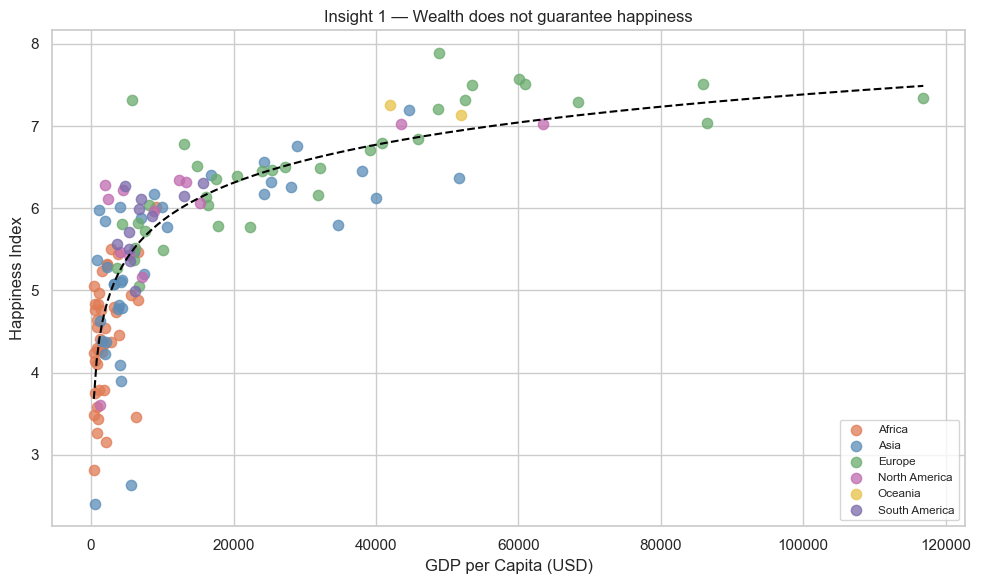

Done! Check your home folder for insight1.png


In [ ]:


    "Africa": "#E07B54",
    "Asia": "#5B8DB8",
    "Europe": "#6AAB6E",
    "North America": "#C06BB0",
    "Oceania": "#E8C24A",
    "South America": "#7B6BAB",
}

df.columns = df.columns.str.strip()
df.rename(columns={
    "Happiness Index ": "Happiness Index",
    "HDI ": "HDI",
    "Inflation Rate (%)": "Inflation Rate",
    "Unemployment Rate (%)": "Unemployment Rate",
    "Renewable Energy Adoption (%)": "Renewable Energy",
    "Pollution Level (PM2.5)": "PM2.5",
    "GDP per Capita (USD)": "GDP per Capita",
}, inplace=True)
df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
df.dropna(subset=["Happiness Index", "GDP per Capita", "HDI", "PM2.5"], inplace=True)

# GDP vs Happiness scatter
fig, ax = plt.subplots(figsize=(10, 6))
for region, grp in df.groupby("Region"):
    ax.scatter(grp["GDP per Capita"], grp["Happiness Index"],
               label=region, alpha=0.75, s=55)
x = df["GDP per Capita"]
y = df["Happiness Index"]
z = np.polyfit(np.log(x + 1), y, 1)
p = np.poly1d(z)
xs = np.linspace(x.min(), x.max(), 300)
ax.plot(xs, p(np.log(xs + 1)), color="black", linewidth=1.5, linestyle="--")
ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("Happiness Index")
ax.set_title("Insight 1 — Wealth does not guarantee happiness")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()
print("Done! Check your home folder for insight1.png")


## 3. Insight 2 — Europe Leads in Happiness AND Lowest Pollution

Comparing regional averages reveals a striking inverse relationship: Europe ranks highest on happiness (~6.2 average) and records the lowest PM2.5 levels. Africa and Asia show the opposite — high pollution, low happiness. This dual burden has direct implications for where development investment should be prioritised.


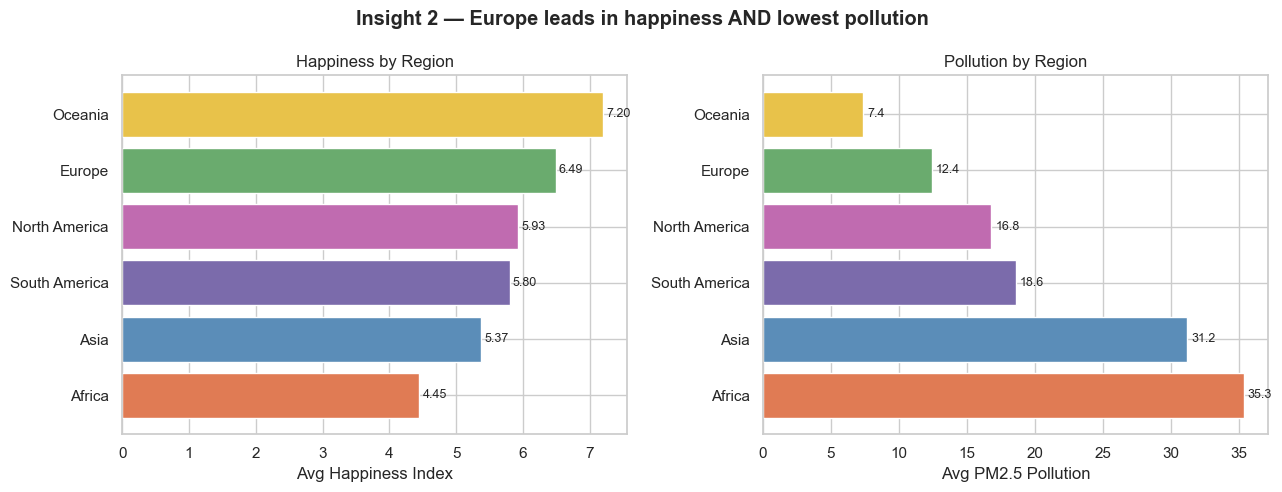

Done!


In [ ]:
# Insight 2 - Regional Happiness and Pollution
region_stats = df.groupby("Region").agg(
    Happiness=("Happiness Index", "mean"),
    PM25=("PM2.5", "mean"),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rs = region_stats["Happiness"].sort_values()
axes[0].barh(rs.index, rs.values, color=[REGION_COLORS.get(r, "gray") for r in rs.index])
for i, v in enumerate(rs.values):
    axes[0].text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)
axes[0].set_xlabel("Avg Happiness Index")
axes[0].set_title("Happiness by Region")

rs2 = region_stats["PM25"].sort_values(ascending=False)
axes[1].barh(rs2.index, rs2.values, color=[REGION_COLORS.get(r, "gray") for r in rs2.index])
for i, v in enumerate(rs2.values):
    axes[1].text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("Avg PM2.5 Pollution")
axes[1].set_title("Pollution by Region")

fig.suptitle("Insight 2 — Europe leads in happiness AND lowest pollution", fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\insight2.png", dpi=150)
plt.show()
print("Done!")

## 4. Insight 3 — Better Governance = Happier Countries

The Corruption Index (higher = less corrupt) shows a strong positive correlation with happiness (r ≈ 0.74). Even controlling roughly for GDP, countries with better governance cluster toward higher happiness scores — positioning institutional quality as an independent driver of wellbeing, not merely a byproduct of wealth.


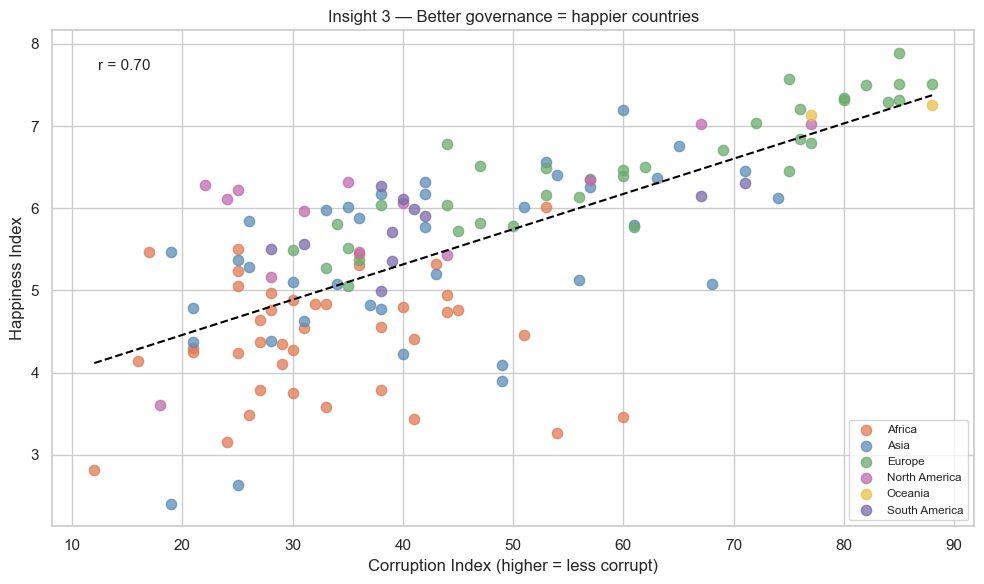

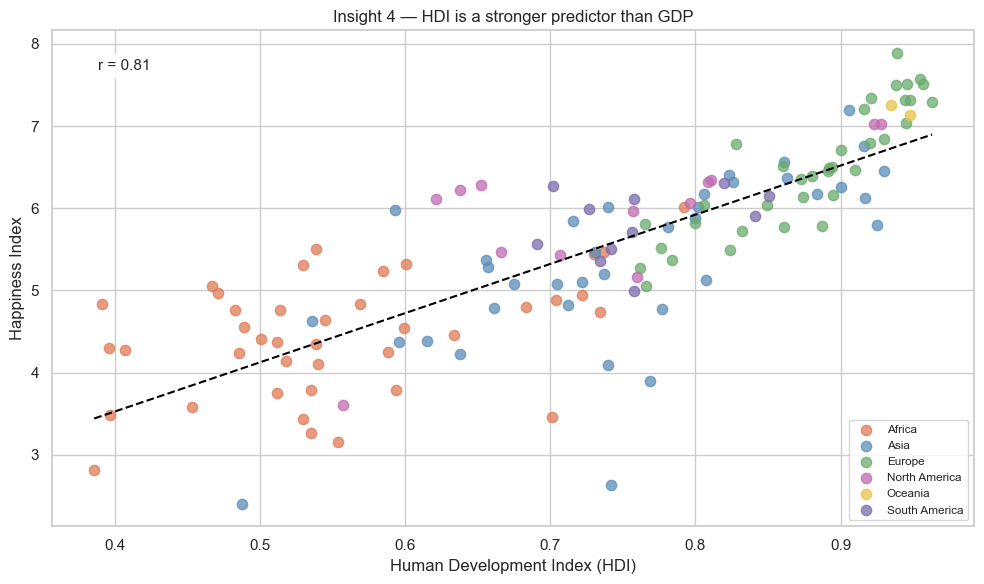

KeyError: "['Life Expectancy', 'Urbanisation'] not in index"

In [ ]:
# Insight 3 - Corruption vs Happiness
fig, ax = plt.subplots(figsize=(10, 6))
for region, grp in df.groupby("Region"):
    ax.scatter(grp["Corruption Index"], grp["Happiness Index"],
               color=REGION_COLORS.get(region, "gray"),
               label=region, alpha=0.75, s=55)
z = np.polyfit(df["Corruption Index"], df["Happiness Index"], 1)
p = np.poly1d(z)
xs = np.linspace(df["Corruption Index"].min(), df["Corruption Index"].max(), 200)
ax.plot(xs, p(xs), color="black", linewidth=1.5, linestyle="--")
r = df["Corruption Index"].corr(df["Happiness Index"])
ax.text(0.05, 0.92, f"r = {r:.2f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white"))
ax.set_xlabel("Corruption Index (higher = less corrupt)")
ax.set_ylabel("Happiness Index")
ax.set_title("Insight 3 — Better governance = happier countries")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\insight3.png", dpi=150)
plt.show()

# Insight 4 - HDI vs Happiness
fig, ax = plt.subplots(figsize=(10, 6))
for region, grp in df.groupby("Region"):
    ax.scatter(grp["HDI"], grp["Happiness Index"],
               color=REGION_COLORS.get(region, "gray"),
               label=region, alpha=0.75, s=55)
z = np.polyfit(df["HDI"], df["Happiness Index"], 1)
p = np.poly1d(z)
xs = np.linspace(df["HDI"].min(), df["HDI"].max(), 200)
ax.plot(xs, p(xs), color="black", linewidth=1.5, linestyle="--")
r = df["HDI"].corr(df["Happiness Index"])
ax.text(0.05, 0.92, f"r = {r:.2f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white"))
ax.set_xlabel("Human Development Index (HDI)")
ax.set_ylabel("Happiness Index")
ax.set_title("Insight 4 — HDI is a stronger predictor than GDP")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\insight4.png", dpi=150)
plt.show()

# Insight 5 - Correlation Heatmap
numeric_cols = ["Happiness Index", "GDP per Capita", "HDI", "Corruption Index",
                "PM2.5", "Life Expectancy", "Education Index", "Unemployment Rate",
                "Renewable Energy", "Urbanisation"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Correlation Heatmap — Which factors drive happiness?", pad=15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\insight5_heatmap.png", dpi=150)
plt.show()
print("All done! 5 charts saved!")


## 5. Insight 4 — Correlation Heatmap: What Actually Drives Happiness?

The full correlation matrix reveals the relative importance of each variable:
- **HDI (r = 0.80)** and **Corruption Index (r = 0.74)** are the strongest predictors
- **Life Expectancy (r = 0.77)** is closely linked — a health proxy
- **PM2.5 pollution (r = -0.45)** has a meaningful negative relationship
- **Renewable Energy** shows low direct correlation but links moderately with HDI


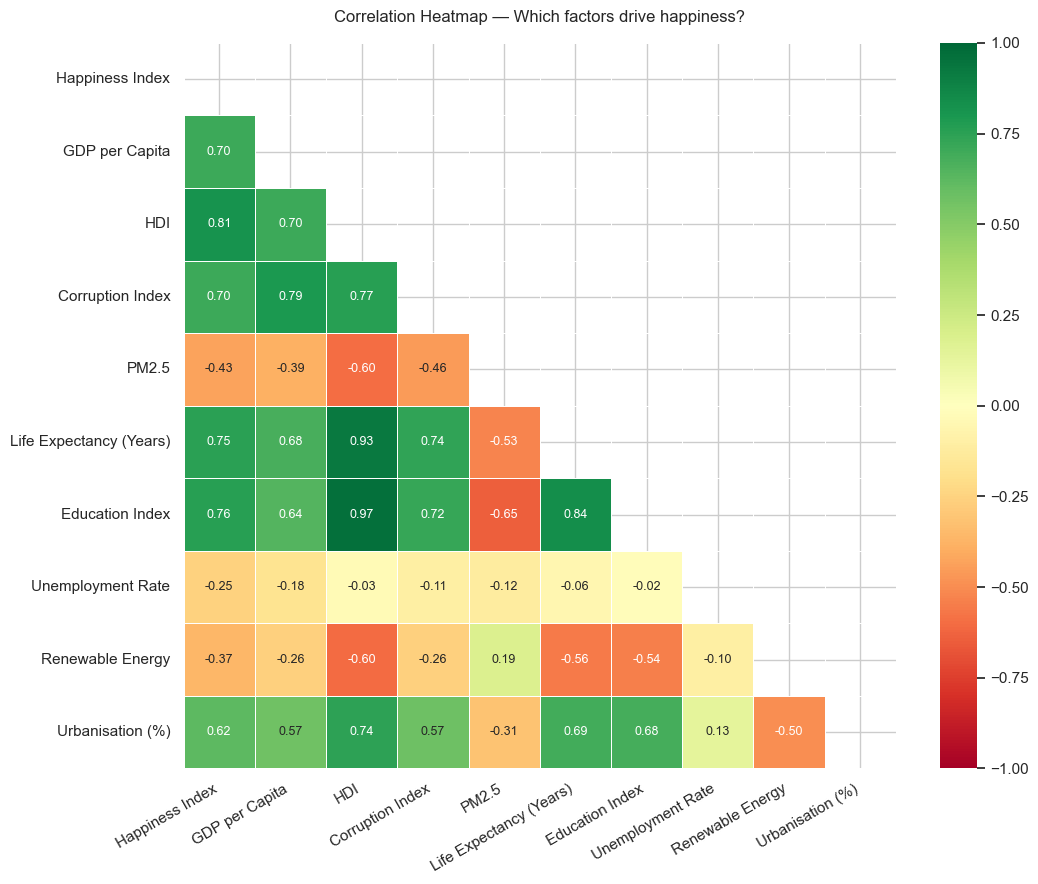

Heatmap done!


In [ ]:
numeric_cols = ["Happiness Index", "GDP per Capita", "HDI", "Corruption Index",
                "PM2.5", "Life Expectancy (Years)", "Education Index", "Unemployment Rate",
                "Renewable Energy", "Urbanisation (%)"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Correlation Heatmap — Which factors drive happiness?", pad=15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\Divyanshi Shaw\insight5_heatmap.png", dpi=150)
plt.show()
print("Heatmap done!")


## 6. Key Findings Summary

| Insight | Finding | Implication |
|---|---|---|
| 1 — GDP vs Happiness | Relationship is logarithmic, not linear | Growth alone insufficient above ~USD 20k per capita |
| 2 — Regional comparison | Europe leads on happiness AND clean air | Africa/Asia face compounding dual burden |
| 3 — Governance | Corruption Index r = 0.74 | Anti-corruption investment has measurable wellbeing returns |
| 4 — HDI vs GDP | HDI r = 0.80 outperforms GDP | Health and education more impactful than income transfers |
| 5 — Heatmap | Life expectancy and HDI dominate | Environmental health is a significant wellbeing component |

---
*Analysis by Divyanshi Shaw — MBusAnalytics candidate, Deakin University*  
*Dataset: Global Sustainability & Peace Index (public dataset)*
